# FEDformer — S&P 500

**Model**: Frequency Enhanced Decomposed Transformer
**Reference**: Zhou et al., 2022 — FEDformer: Frequency Enhanced Decomposed Transformer for Long-term Series Forecasting

## Description
This notebook implements the **FEDformer** Transformer architecture for univariate time-series
forecasting on the S&P 500 dataset. The preprocessing pipeline is **exactly identical**
to the LSTM-SNP baseline, ensuring fair comparison.

**Experiment Protocol**: 30 independent runs × 100 epochs each

In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import random
import time
import time as _timer_module
import torch
import torch.nn as nn

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Theory: FEDformer Architecture

### Frequency Enhanced Attention
FEDformer operates in the **frequency domain** rather than the time domain:

1. Transform input to frequency space via FFT: $X_f = \mathcal{F}(X)$
2. Randomly select $M$ Fourier modes (random mode selection)
3. Apply learned linear transformations to selected modes
4. Transform back via inverse FFT: $X = \mathcal{F}^{-1}(X_f)$

### Frequency Domain Mixing
The Fourier block applies learned complex-valued weights:
$$Y_f[m] = W \cdot X_f[m], \quad m \in \{\text{selected modes}\}$$

where $W = W_{\text{real}} + i \cdot W_{\text{imag}}$ is a learnable complex weight matrix.

### Series Decomposition
Like Autoformer, FEDformer uses moving-average decomposition at each layer to separate trend and seasonal components.

### Complexity
By selecting only $M \ll L$ Fourier modes, FEDformer achieves $O(L)$ complexity.

## Model Architecture & Implementation

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Forcing CPU execution.')
print(f'\nUsing device: {device}')
print(f'PyTorch version: {torch.__version__}')


In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================


print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================


PyTorch version: 2.11.0
NumPy version: 2.4.4
Using device: cpu


### Seed Control

In [2]:
# ============================================================
# Seed Control — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        # MPS seed is set via torch.manual_seed
        pass


### FEDformer Model Definition

In [3]:
# ============================================================
# FEDformer: Frequency Enhanced Decomposed Transformer
# Reference: Zhou et al., 2022
#
# Key ideas:
# 1. Frequency attention: attention in Fourier space via random
#    mode selection (keeps top-M Fourier modes)
# 2. Series decomposition (shared with Autoformer)
# 3. Mixture of Experts (MoE) for frequency domain processing
# ============================================================

class FourierBlock(nn.Module):
    """
    Fourier-based attention block.
    Operates in the frequency domain by selecting random Fourier modes
    and applying learned linear transformations.
    """
    def __init__(self, d_model, n_modes=8):
        super().__init__()
        self.d_model = d_model
        self.n_modes = n_modes

        # Learnable complex weights for frequency domain
        self.scale = 1.0 / d_model
        self.W_real = nn.Parameter(self.scale * torch.randn(d_model, d_model))
        self.W_imag = nn.Parameter(self.scale * torch.randn(d_model, d_model))

    def forward(self, x):
        # x: (B, L, D)
        B, L, D = x.shape

        # FFT along sequence dimension
        x_fft = torch.fft.rfft(x, dim=1)  # (B, L//2+1, D)
        freq_len = x_fft.shape[1]

        # Select modes (all modes for short sequences)
        n_modes = min(self.n_modes, freq_len)

        # Apply learnable frequency transform on selected modes
        out_fft = torch.zeros_like(x_fft)
        selected = x_fft[:, :n_modes, :]

        # Complex multiplication with learned weights
        W_complex = torch.complex(self.W_real, self.W_imag)
        selected_out = torch.einsum('bld,dd->bld', selected, W_complex)
        out_fft[:, :n_modes, :] = selected_out

        # Inverse FFT
        output = torch.fft.irfft(out_fft, n=L, dim=1)  # (B, L, D)
        return output


class FEDSeriesDecomposition(nn.Module):
    """Series decomposition via moving average (shared design)."""
    def __init__(self, kernel_size=3):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.avg_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=padding)

    def forward(self, x):
        trend = self.avg_pool(x.transpose(1, 2)).transpose(1, 2)
        seasonal = x - trend
        return seasonal, trend


class FEDformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_modes=8, dropout=0.1):
        super().__init__()
        self.fourier_block = FourierBlock(d_model, n_modes)
        self.decomp1 = FEDSeriesDecomposition(kernel_size=3)
        self.decomp2 = FEDSeriesDecomposition(kernel_size=3)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Fourier block + decomposition
        fourier_out = self.fourier_block(x)
        x = x + self.dropout(fourier_out)
        seasonal1, trend1 = self.decomp1(x)

        # Feed-forward + decomposition
        ff_out = self.ff(seasonal1)
        seasonal2, trend2 = self.decomp2(seasonal1 + ff_out)

        return seasonal2 + trend1 + trend2


class FEDformerModel(nn.Module):
    """
    FEDformer for univariate time-series forecasting.
    Input: (batch, seq_len=1, 1) → Output: (batch, 1)
    """
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64,
                 n_modes=8, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, d_model) * 0.02)
        self.encoder_layers = nn.ModuleList([
            FEDformerEncoderLayer(d_model, n_heads, d_ff, n_modes, dropout)
            for _ in range(n_layers)
        ])
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_embedding[:, :L, :]

        for layer in self.encoder_layers:
            x = layer(x)

        x = x[:, -1, :]
        return self.output_proj(x)

In [4]:
# Quick model check
set_seed(0)
test_model = FEDformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, dropout=0.1).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Memory estimate: {total_params * 4 / 1024:.1f} KB")

# Test forward pass
dummy = torch.randn(1, 1, 1).to(device)
out = test_model(dummy)
print(f"Input shape: {dummy.shape}, Output shape: {out.shape}")
del test_model, dummy, out

Total parameters: 15905
Trainable parameters: 15905
Memory estimate: 62.1 KB
Input shape: torch.Size([1, 1, 1]), Output shape: torch.Size([1, 1])


## Data Pipeline — S&P 500

In [5]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (251,)
First 5 values: [2038.199951 2013.780029 2011.709961 1985.319946 1945.969971]


In [6]:
# ============================================================
# 2. First-Order Differencing — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [7]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
#    IDENTICAL to LSTM-SNP pipeline
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (250, 2)


In [8]:
# ============================================================
# 4. Train-Test Split — IDENTICAL to LSTM-SNP pipeline
# ============================================================

train, test = supervised[:-60], supervised[-60:]
print(f"Train: {train.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling — IDENTICAL to LSTM-SNP pipeline
# ============================================================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

Train: (190, 2), Test: (60, 2)


In [9]:
# ============================================================
# 6. Prepare Data for Model
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (190, 1, 1), y_train shape: (190,)


## Training Loop

In [10]:
# ============================================================
# 30-Run Experiment Protocol — IDENTICAL to LSTM-SNP pipeline
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []
all_times = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')
    start_time = time.time()

    # Set seed — IDENTICAL to LSTM-SNP: np.random.seed(run), etc.
    set_seed(run)

    # Build model
    model = FEDformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64,
                          n_layers=2, dropout=0.1).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Convert data to tensors
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)

    # Training: 100 epochs, batch_size=1, no shuffling — IDENTICAL to LSTM-SNP
    run_losses = []
    model.train()
    for epoch in range(100):
        epoch_loss = 0.0
        for i in range(len(X_tr)):
            x_sample = X_tr[i:i+1]  # (1, 1, 1)
            y_sample = y_tr[i:i+1]  # (1, 1)

            optimizer.zero_grad()
            output = model(x_sample)
            loss = criterion(output, y_sample)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(X_tr)
        run_losses.append(avg_loss)

    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')

    # Test predictions (single-step) — IDENTICAL inverse transform to LSTM-SNP
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(len(test_scaled)):
            X = test_scaled[i, 0:-1]
            X_input = torch.FloatTensor(X.reshape(1, 1, -1)).to(device)
            yhat = model(X_input).cpu().numpy()[0, 0]

            # Invert scaling — IDENTICAL to LSTM-SNP
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]

            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)

            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics — IDENTICAL to LSTM-SNP
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    elapsed = time.time() - start_time

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    all_times.append(elapsed)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}, Time: {elapsed:.1f}s')


===== RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=2156.6186, Expected=2158.2200
Month=2, Predicted=2158.9827, Expected=2164.1899
Month=3, Predicted=2164.6693, Expected=2160.3899
Month=4, Predicted=2161.6377, Expected=2161.3501
Month=5, Predicted=2162.2868, Expected=2137.6699
Month=6, Predicted=2139.7463, Expected=2130.2600
Month=7, Predicted=2131.6915, Expected=2139.6799
Month=8, Predicted=2139.7553, Expected=2132.9500
Month=9, Predicted=2134.3492, Expected=2138.3101
Month=10, Predicted=2138.8534, Expected=2140.8101
Month=11, Predicted=2141.6224, Expected=2142.5100
Month=12, Predicted=2143.3886, Expected=2139.4299
Month=13, Predicted=2140.6366, Expected=2148.5000
Month=14, Predicted=2148.6193, Expected=2149.7200
Month=15, Predicted=2150.6366, Expected=2136.9700
Month=16, Predicted=2138.6301, Expected=2144.0601
Month=17, Predicted=2144.4158, Expected=2132.2300
Month=18, Predicted=2133.8529, Expected=2129.7800
Month=19, Predicted=2130.9492, Expected=2128.6799
Month=20,

## Results

In [11]:
# ============================================================
# Summary Statistics (30 runs) — IDENTICAL format to LSTM-SNP
# ============================================================

print('\n===== FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
print(f'Avg training time: {np.mean(all_times):.1f}s ± {np.std(all_times):.1f}s')

best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — FEDformer on S&P 500 (30 runs) =====
RMSE: 11.143775 ± 0.032248
MSE:  124.184766 ± 0.717944
NMSE: 0.0007552581 ± 0.0000058618
Avg training time: 52.0s ± 18.8s

Best run: 30
  RMSE: 11.078949
  MSE:  122.743109
  NMSE: 0.0007435373


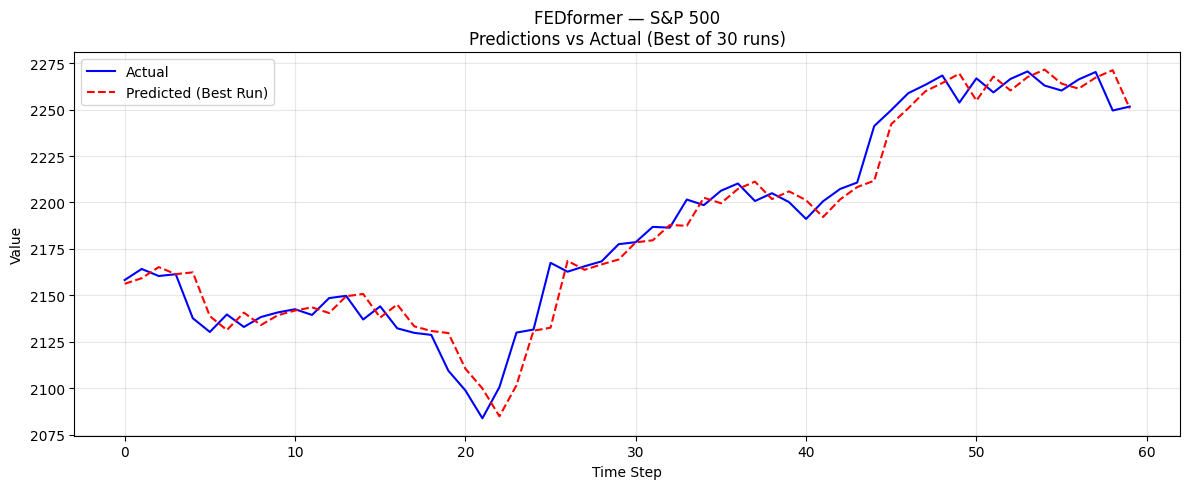

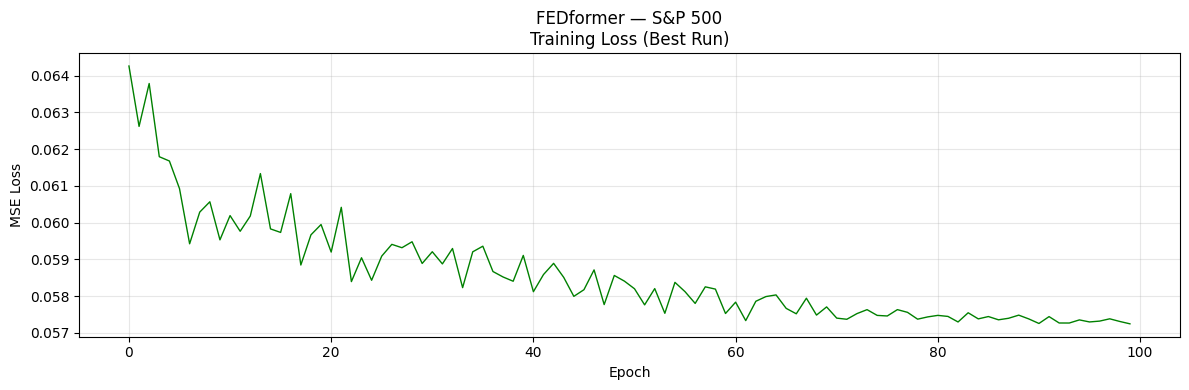

=== Best Run Metrics ===
RMSE: 11.078949
MSE:  122.743109
NMSE: 0.0007435373


In [12]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('FEDformer — S&P 500\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('FEDformer — S&P 500\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Export Predictions

In [13]:
# ============================================================
# Save Predictions to CSV
# ============================================================

actual = raw_values[-60:]
results_df = pd.DataFrame({
    'Actual': actual,
    'Predicted_BestRun': all_predictions[best_idx],
})
for i in range(30):
    results_df[f'Predicted_Run_{i+1}'] = all_predictions[i]

csv_filename = 'FEDformer_SP500_predictions.csv'
results_df.to_csv(csv_filename, index=False)
print(f'Predictions saved to {csv_filename}')

Predictions saved to FEDformer_SP500_predictions.csv


## Observations

### FEDformer on S&P 500

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with LSTM-SNP variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Compare training time with LSTM-SNP
5. **Model Size**: Note parameter count vs LSTM-SNP (~361 params)

*After running all 5 model notebooks per dataset, perform cross-model comparison to evaluate
whether Transformer architectures improve over LSTM-SNP for these time series datasets.*

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
